# EXPLORATION 01

In [8]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


## 1. 인물 사진

### (1) 인물 사진 준비하기

이미지 크기: (4000, 3000, 3)


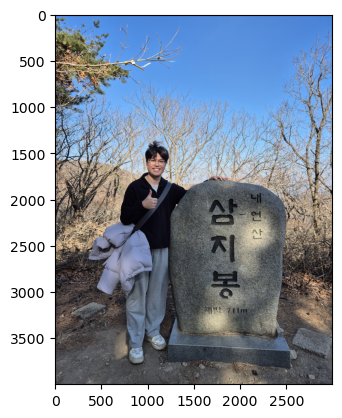

In [32]:
# 인물 사진 불러오기
home_dir = os.getenv('HOME')
human_img_path = os.path.join(home_dir, "work/Ex01/images/person.jpg")  # 인물 사진 이미지 경로
human_img_orig = cv2.imread(human_img_path)

print(f"이미지 크기: {human_img_orig.shape}")

# 이미지 시각화
plt.imshow(cv2.cvtColor(human_img_orig, cv2.COLOR_BGR2RGB))
plt.show()

### (2) Segmentation으로 사람 분리하기

In [15]:
# DeepLab 모델을 준비
model = deeplabv3_resnet101(pretrained=True).eval()

# 이미지 입력 크기 조정
transform_to_tensor = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

# 전처리
input_tensor = transform(cv2.cvtColor(human_img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [16]:
# 모델에 이미지 입력
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (human_img_orig.shape[1], human_img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

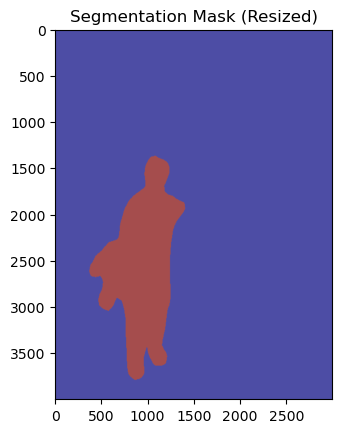

In [17]:
# 모델에서 나온 출력값 확인
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [21]:
# 어떤 클래스가 있는지 확인
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]

unique_classes = np.unique(output_predictions_resized)

for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


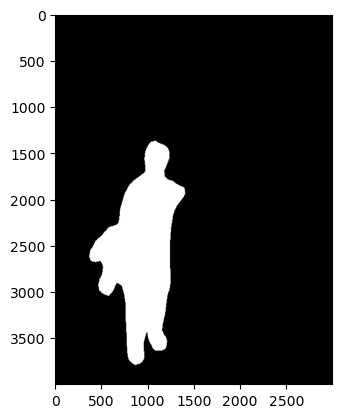

In [22]:
# 사람만 표시된 마스크 만들기
seg_map = (output_predictions_resized == 15)  # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

### (3) 배경 흐리게 하기

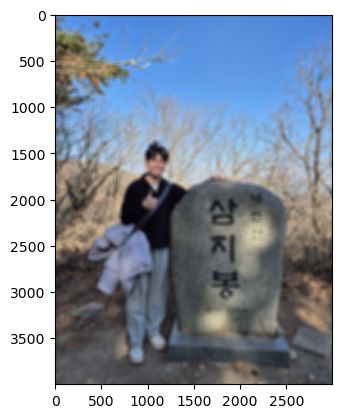

In [27]:
# blur() 함수 이용해서 배경 흐리게 하기
img_orig_blur = cv2.blur(human_img_orig, (50, 50))
plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

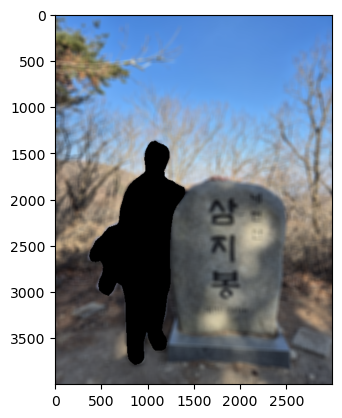

In [28]:
# 흐려진 이미지에서 segmentation mask를 이용해서 배경 추출
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
img_bg_mask = cv2.bitwise_not(img_mask_color)
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

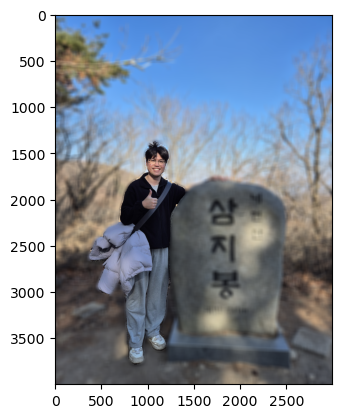

In [30]:
# 배경 사진과 사람 사진 합치기
img_concat = np.where(img_mask_color==255, human_img_orig, img_bg_blur)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

## 2. 동물 사진

### (1) 동물 사진 준비

이미지 크기: (4000, 3000, 3)


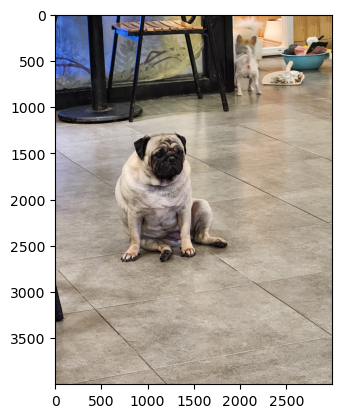

In [33]:
animal_img_path = os.path.join(home_dir, "work/Ex01/images/dog.jpg")  # 인물 사진 이미지 경로
animal_img_orig = cv2.imread(animal_img_path)

print(f"이미지 크기: {animal_img_orig.shape}")

# 이미지 시각화
plt.imshow(cv2.cvtColor(animal_img_orig, cv2.COLOR_BGR2RGB))
plt.show()

### (2) Segmentation

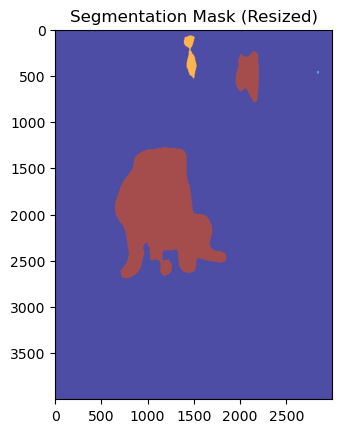

In [35]:
# 전처리
input_tensor = transform(cv2.cvtColor(animal_img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

# 모델에 이미지 입력
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (animal_img_orig.shape[1], animal_img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

# 모델에서 나온 출력값 확인
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [36]:
# 어떤 클래스가 있는지 확인
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]

unique_classes = np.unique(output_predictions_resized)

for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
boat
chair
dog


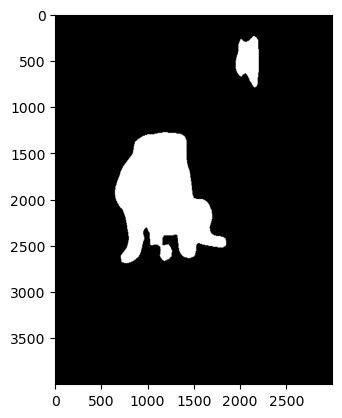

In [37]:
# 동물만 표시된 마스크 만들기
seg_map = (output_predictions_resized == 12)  # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

### (3) 배경 흐리게 하기

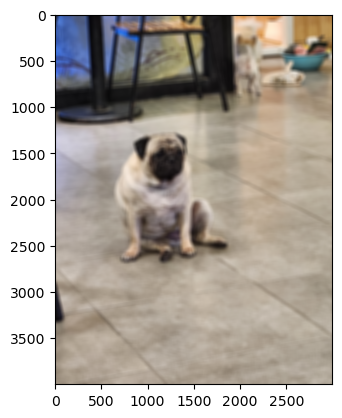

In [38]:
# blur() 함수 이용해서 배경 흐리게 하기
img_orig_blur = cv2.blur(animal_img_orig, (50, 50))
plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

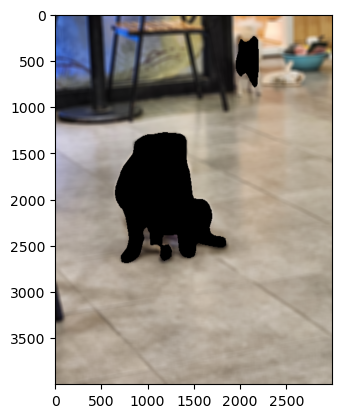

In [39]:
# 흐려진 이미지에서 segmentation mask를 이용해서 배경 추출
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
img_bg_mask = cv2.bitwise_not(img_mask_color)
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

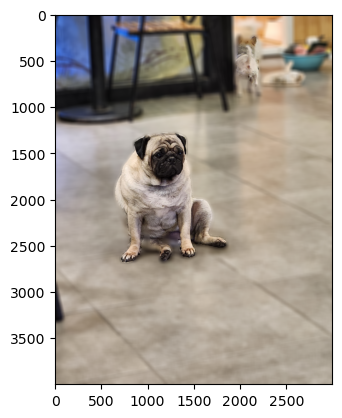

In [40]:
# 배경 사진과 사람 사진 합치기
img_concat = np.where(img_mask_color==255, animal_img_orig, img_bg_blur)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

## 3. 배경전환 크로마키사진

사람 이미지 크기: (4000, 3000, 3)
배경 이미지 크기: (3000, 4000, 3)


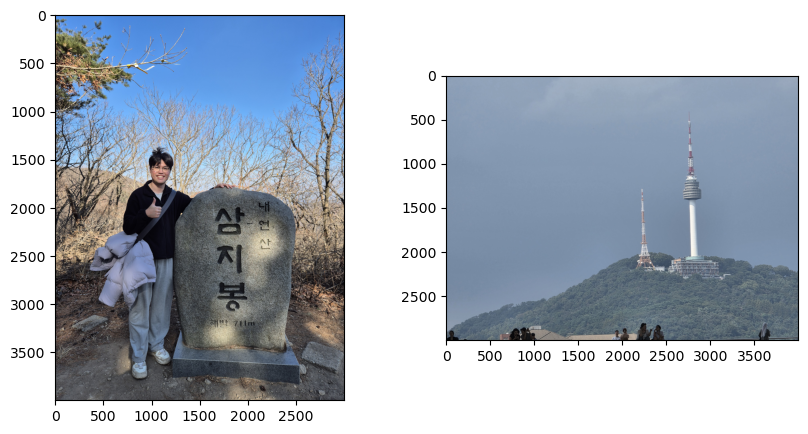

In [42]:
human_img_path = os.path.join(home_dir, "work/Ex01/images/person.jpg")  # 인물 사진 이미지 경로
background_img_path = os.path.join(home_dir, "work/Ex01/images/background.jpg")  # 배경 이미지 경로

human_img = cv2.imread(human_img_path)
background_img = cv2.imread(background_img_path)

human_img = cv2.cvtColor(human_img, cv2.COLOR_BGR2RGB)
background_img = cv2.cvtColor(background_img, cv2.COLOR_BGR2RGB)

print(f"사람 이미지 크기: {human_img.shape}")
print(f"배경 이미지 크기: {background_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(human_img)

plt.subplot(1, 2, 2)
plt.imshow(background_img)

plt.show()

In [43]:
# 사람 이미지 전처리 후 모델에 입력
input_tensor = transform(human_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


추론 마스크 크기 (After Resize): (4000, 3000)


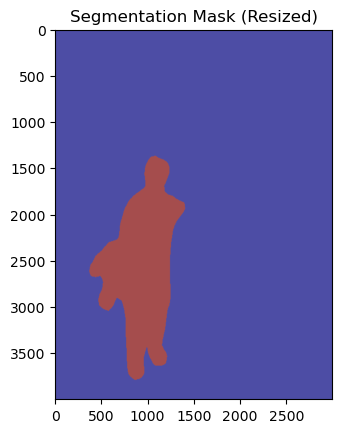

In [44]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (human_img.shape[1], human_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

# 모델에서 나온 출력값 확인
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [45]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [ 0 15]


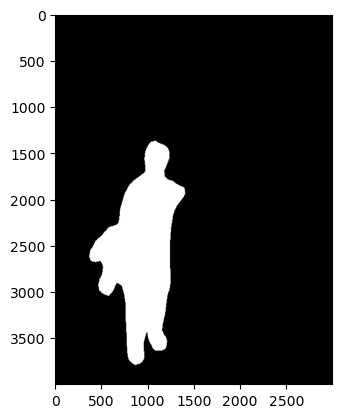

In [46]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

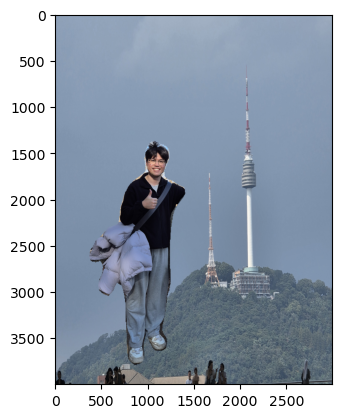

In [47]:
# 배경을 사람 이미지 크기에 맞춤
background_img_resized = cv2.resize(background_img, (human_img.shape[1], human_img.shape[0]))

# 사람 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, human_img, background_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

## 프로젝트 진행하면서 회고
사람과 동물 주변이 깔끔한 사진을 사용해서 그런지 segmentation도 어느 정도 잘되었던것 같고, 아웃포커싱 효과도 잘 구현된것 같다. 하지만 동물 사진 아웃포커싱 구현하는 도중에 segmentation을 하는데 뒤의 의자가 잘 안되는 것을 볼 수 있었다. 이 문제를 어떻게 하면 개설할 수 있을지 고민해보았다. 문제는 다음과 같다. 노란색으로 표시한 부분을 잘 인식할 수 있도록 해결해보겠다.

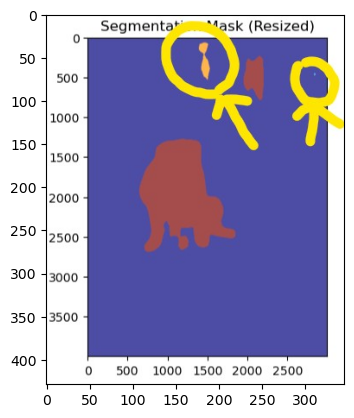

In [49]:
# 문제 사진 불러오기
problem_img_path = os.path.join(home_dir, "work/Ex01/images/problem.jpg")  # 인물 사진 이미지 경로
problem_img_orig = cv2.imread(problem_img_path)

# 이미지 시각화
plt.imshow(cv2.cvtColor(problem_img_orig, cv2.COLOR_BGR2RGB))
plt.show()

## (1) 첫번째 아이디어: 검색을 해보니 deeplabv3의 최신 weight가 있는것 같다. weight를 최신 것으로 업데이트 해본다.

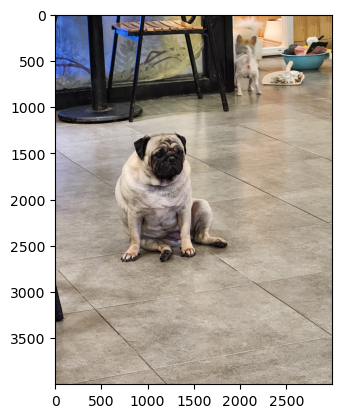

In [51]:
dog_img_path = os.path.join(home_dir, "work/Ex01/images/dog.jpg")  # 인물 사진 이미지 경로
dog_img_orig = cv2.imread(dog_img_path)

# 이미지 시각화
plt.imshow(cv2.cvtColor(dog_img_orig, cv2.COLOR_BGR2RGB))
plt.show()

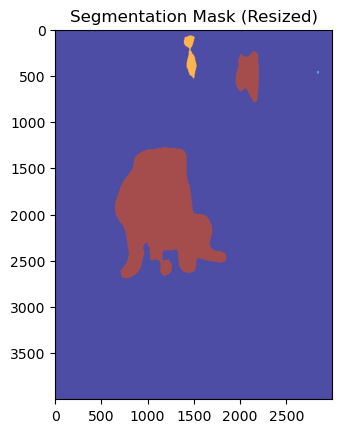

In [57]:
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
# DeepLab 모델을 준비
weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights).eval()

# 이미지 입력 크기 조정
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

# 전처리
input_tensor = transform(cv2.cvtColor(dog_img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

# 모델에 이미지 입력
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (dog_img_orig.shape[1], dog_img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

# 모델에서 나온 출력값 확인
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()



### weight를 최신것으로 해봤지만 결과는 똑같아 보인다. 다음 해결책으로 넘어가본다.

## (2) 두번째 아이디어: 검색을 해보니 모델 권장 전처리(정규화)를 추가할 수 있다.

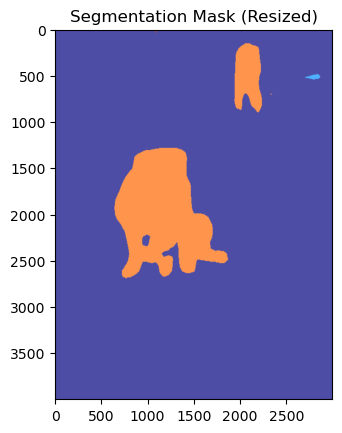

In [60]:
from PIL import Image

# DeepLab 모델 준비
weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights).eval()

# 권장 전처리 사용 (정규화 등 포함)
preprocess = weights.transforms()

# PIL 변환 → 리사이즈 → 권장 전처리 적용
pil_img = Image.fromarray(cv2.cvtColor(dog_img_orig, cv2.COLOR_BGR2RGB))
pil_img = pil_img.resize((520, 520))
input_tensor = preprocess(pil_img).unsqueeze(0)

# 모델에 이미지 입력
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(
    output_predictions,
    (dog_img_orig.shape[1], dog_img_orig.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [62]:
# 어떤 클래스가 있는지 확인
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]

unique_classes = np.unique(output_predictions_resized)

for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
boat
dog
person


### 결과: 전처리를 추가해주니 노란색으로 표시했던 부분 중에 의자 부분이 없어졌고, dog 부분의 segmentation 성능이 올라갔다. 아까는 다리가 잘려보였는데 지금 결과를 보면 다리까지 segmentation이 잘되었다.

## (2) 두번째 아이디어: 종횡비 유지 리사이즈 + 권장 전처리
### 520×520 강제 리사이즈 대신 종횡비를 유지하면서 긴 쪽을 520에 맞춤

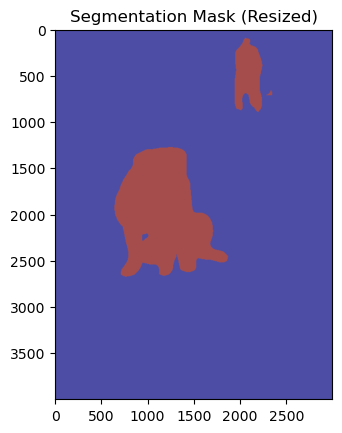

In [65]:
# PIL 변환
pil_img = Image.fromarray(cv2.cvtColor(dog_img_orig, cv2.COLOR_BGR2RGB))

# ✅ 종횡비 유지하면서 리사이즈 (긴 쪽을 520으로)
w, h = pil_img.size
if h > w:
    new_h = 520
    new_w = int(w * (520 / h))
else:
    new_w = 520
    new_h = int(h * (520 / w))

pil_img_resized = pil_img.resize((new_w, new_h), Image.BILINEAR)
input_tensor = preprocess(pil_img_resized).unsqueeze(0)

# 모델에 이미지 입력
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(
    output_predictions,
    (dog_img_orig.shape[1], dog_img_orig.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [66]:
unique_classes = np.unique(output_predictions_resized)

for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
dog


### 결과: 사이즈를 조정하니까 의자가 없어지고, dog와 background 클래스만 남았다.